In [43]:
import pickle
import numpy as np
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import boule as bl
import pyshtools as pysh

In [44]:
PROJECT_ROOT = Path.cwd().parent

In [45]:
plt.rcParams['font.sans-serif'] = ['SimHei']      # 黑体
plt.rcParams['axes.unicode_minus'] = False        # 解决负号显示问题

月壳厚度数据

In [46]:
PROJECT_ROOT = Path.cwd().parent
pkl_file=PROJECT_ROOT/"result/run_approach.pkl"

with open(pkl_file, "rb") as f:
    obj = pickle.load(f, encoding="latin1")

    # 提取所需变量并转为 numpy array
    density = np.asarray(obj['densities'])
    reference_levels = np.asarray(obj['reference_levels'])
    score_refden = np.asarray(obj['scores_refden'])
    score_regul = np.asarray(obj['scores_regul'])
    regul = np.asarray(obj['regul_params'])
    regul_residual = np.asarray(obj['regul_residuals'])
    refden_residual = np.asarray(obj['refden_residuals'])

    refden_moho_grid = obj['best_solutions_refden_moho_grid']
    refden_predict_grid = obj['best_solutions_refden_predict_grid']
    observe = obj['observe']
    lon = obj['lon']
    lat = obj['lat']
    lon_sub = obj['lon_sub']
    lat_sub = obj['lat_sub']
    
nlat_moho, nlon_moho = refden_moho_grid.shape
lon_moho = np.linspace(lon.min(), lon.max(), nlon_moho)
lat_moho = np.linspace(lat.min(), lat.max(), nlat_moho)

moho_grid = xr.DataArray(
    refden_moho_grid,  # 如果图东西颠倒或拉伸，改为 refden_moho_grid.T
    dims=("lat", "lon"),
    coords={"lat": lat_moho, "lon": lon_moho}
)

data_file = PROJECT_ROOT/"data/boueguer_frenquency_11km_withoutmoremare_topo_1deg.csv"

df = pd.read_csv(data_file)
lon_raw = np.sort(df['lon'].unique())
lat_raw = np.sort(df['lat'].unique())
nlat = len(np.unique(lat_raw))
nlon = len(np.unique(lon_raw))

topo_grid  = df.pivot(index='lat', columns='lon', values='topo').loc[lat_raw, lon_raw].values
LON, LAT = np.meshgrid(lon_raw, lat_raw) 

arr = topo_grid + bl.Moon2015.mean_radius

nlon = arr.shape[1]
half = nlon // 2

arr_shifted = np.hstack([
    arr[:, half:],   # 后一半列
    arr[:, :half]    # 前一半列
])
topo_da = xr.DataArray(
    arr_shifted,  # 如果图东西颠倒或拉伸，改为 refden_moho_grid.T
    dims=("lat", "lon"),
    coords={"lat": lat_raw, "lon": lon_raw}
)

region = [lon_raw.min(), lon_raw.max(), lat_raw.min(), lat_raw.max()]

topo_da=topo_da.interp_like(moho_grid)

thick_da=topo_da-moho_grid
thick_da.values=thick_da.values
topo_da.values=topo_da.values

In [47]:
topo = pysh.datasets.Moon.LDEM_shape_pa()
topo_grid = topo.expand(grid="DH2", lmax=1200, extend=False)
topo_xr = topo_grid.to_xarray()

In [48]:
lon = thick_da.lon.values
lon = (lon + 360) % 360

thick_da = thick_da.assign_coords(lon=lon)

月球地形数据

In [ ]:
def plot_equatorial(topo_xr,thick_da):
    thick_da=thick_da.interp_like(topo_xr,method="linear",kwargs={"fill_value": "extrapolate"})
    moho_da=topo_xr-thick_da
    topo_eq = topo_xr.sel(lat=0, method="nearest")
    moho_eq = moho_da.sel(lat=0, method="nearest")
    
    theta = np.deg2rad(topo_eq.lon.values)
    Rmoon = 1737.4*1e3  # km
    
    # 处理数据
    R_surface = topo_eq.values - Rmoon
    R_moho = moho_eq.values - Rmoon

    # 处理 NaN
    mask = np.isfinite(R_surface) & np.isfinite(R_moho)
    theta_plot = theta[mask]
    R_surface_plot = R_surface[mask]
    R_moho_plot = R_moho[mask]

    plt.rcParams.update({
        "font.family": "sans-serif",
        "font.size": 15,
        "axes.linewidth": 1,
    })

    fig = plt.figure(figsize=(6,6))
    ax = plt.subplot(111, projection="polar")

    # ----------------------
    # mantle 填充
    # ----------------------
    rmin = np.nanmin(R_moho_plot)
    ax.fill_between(theta_plot, rmin, R_moho_plot, color="0.92", zorder=0)

    # ----------------------
    # crust 按区间填充
    # 分界线：3°E, 100°E, 55°W(305°E)
    # ----------------------
    boundaries_deg = [3, 100, 295]
    boundaries_deg = np.array(boundaries_deg)

    # 定义区间
    regions = [
        (295, 360),
        (0, 3),
        (3, 100),
        (100, 295)
    ]

    # 颜色，每个区间不同
    colors = ["#E6AB02", "#E6AB02", "#1B9E77", "#7570B3"]

    # 填充
    for (lon0, lon1), color in zip(regions, colors):
        t0 = np.deg2rad(lon0)
        t1 = np.deg2rad(lon1)
        if t1 < t0:  # 跨 0°
            mask_region = (theta_plot >= t0) | (theta_plot < t1)
        else:
            mask_region = (theta_plot >= t0) & (theta_plot < t1)
        ax.fill_between(
            theta_plot[mask_region],
            R_moho_plot[mask_region],
            R_surface_plot[mask_region],
            color=color,
            alpha=0.8,
            zorder=1
        )

    # ----------------------
    # Moho & surface 线
    # ----------------------
    ax.plot(theta_plot, R_surface_plot, color="black", lw=1.8, label="表面", zorder=3)
    ax.plot(theta_plot, R_moho_plot, color="0.35", lw=1.5, label="莫霍面", zorder=4)

    # ----------------------
    # 分界线
    # ----------------------
    for lon in boundaries_deg:
        t = np.deg2rad(lon)
        ax.plot([t, t], [np.nanmin(R_moho_plot), np.nanmax(R_surface_plot)],
                color="black", lw=1.2, zorder=5)

    # ----------------------
    # 极坐标设置
    # ----------------------
    ax.set_theta_zero_location("E")
    ax.set_theta_direction(-1)
    ax.set_thetagrids([0,45,90,135,180,225,270,315],
                    labels=["0°","45°E","90°E","135°E","180°","135°W","90°W","45°W"])
    ax.spines['polar'].set_visible(False)

    # 半径范围
    ax.set_rlim(-150*1e3, 15*1e3)

    # 径向刻度
    r_ticks = np.arange(-100e3, 20e3, 50e3)
    ax.set_rticks(r_ticks)
    ax.set_yticklabels([f"{int(r/1000)} km" for r in r_ticks])
    ax.set_rlabel_position(135)

    # 图例
    #ax.legend(frameon=False, loc="upper right")


    plt.tight_layout()
    plt.show()
    
    return fig

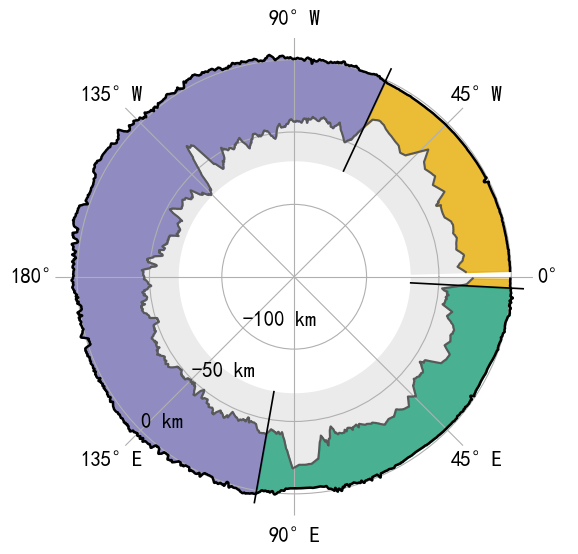

In [77]:
fig=plot_equatorial(topo_xr,thick_da)

In [ ]:
fig.savefig(PROJECT_ROOT/"plotting/figure/空间域_赤道剖面图.png",dpi=600)